In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering as SklearnAgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from agglomerative import AgglomerativeClustering

X, y = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

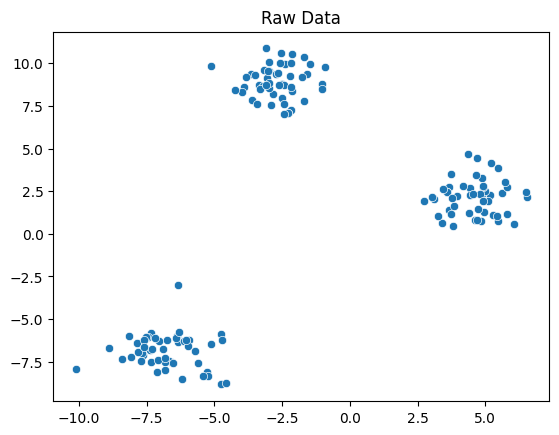

In [2]:
sns.scatterplot(x=X[:, 0], y=X[:, 1])
plt.title("Raw Data")
plt.show()

# Scikit Implementation

In [3]:
model = SklearnAgglomerativeClustering(n_clusters=3, linkage="ward", compute_distances=True)
labels_sklearn = model.fit_predict(X)

## Dendrogram

In [4]:
def plot_dendrogram(children, distances, n_samples, **kwargs):
    counts = np.zeros(children.shape[0])
    for i, merge in enumerate(children):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [children, distances, counts]
    ).astype(float)
    dendrogram(linkage_matrix, **kwargs)

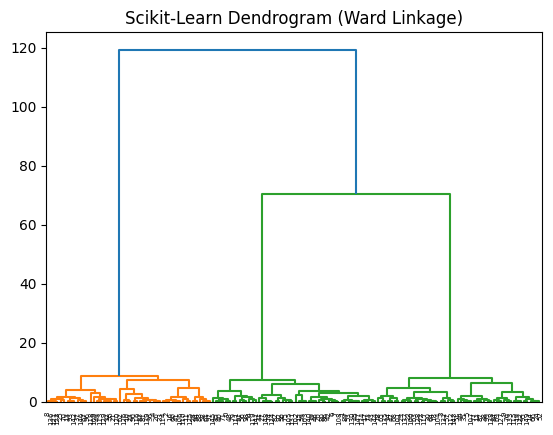

In [5]:
plot_dendrogram(model.children_, model.distances_, X.shape[0])
plt.title("Scikit-Learn Dendrogram (Ward Linkage)")
plt.show()

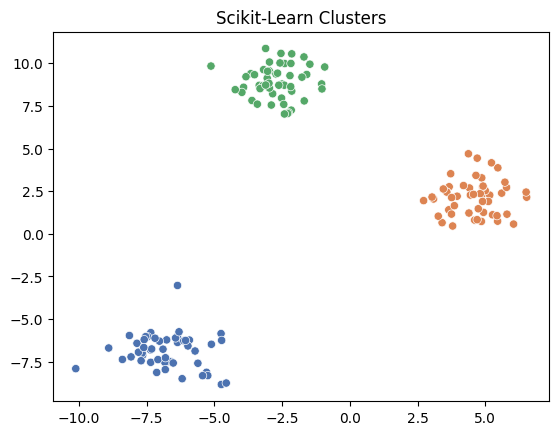

In [6]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_sklearn, palette="deep", legend=False)
plt.title("Scikit-Learn Clusters")
plt.show()

# My AgglomerativeClustering

In [7]:
my_model = AgglomerativeClustering(linkage="ward")
my_model.fit(X)

## Dendrogram

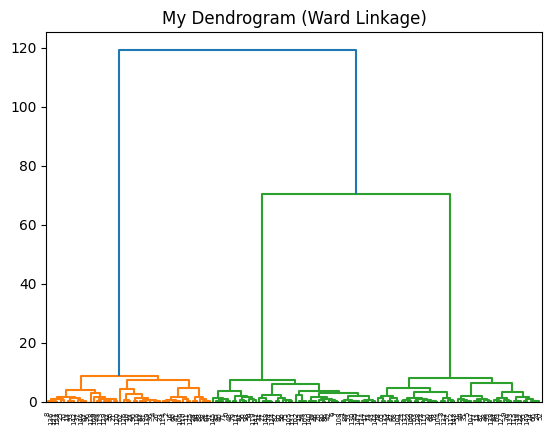

In [8]:
plot_dendrogram(my_model.children_[:, :2].astype(int), my_model.distances_, X.shape[0])
plt.title("My Dendrogram (Ward Linkage)")
plt.show()

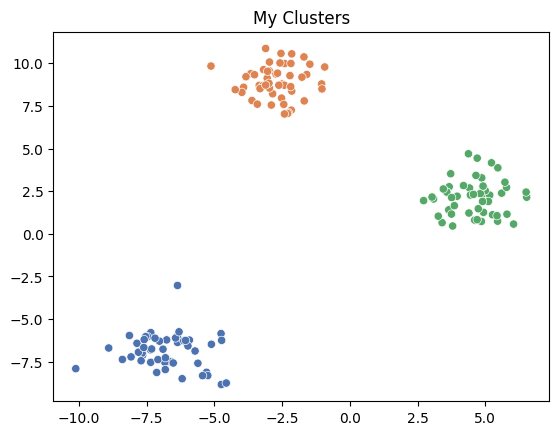

Adjusted Rand Score vs scikit-learn: 1.000


In [9]:
n_samples = X.shape[0]
Z = np.column_stack([
    my_model.children_[:, 0],
    my_model.children_[:, 1],
    my_model.distances_,
    my_model.children_[:, 3],
]).astype(float)

my_labels = fcluster(Z, t=3, criterion="maxclust")

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=my_labels, palette="deep", legend=False)
plt.title("My Clusters")
plt.show()

print(f"Adjusted Rand Score vs scikit-learn: {adjusted_rand_score(labels_sklearn, my_labels):.3f}")

## Validating Other Linkage Criteria

In [10]:
for method in ["single", "complete", "average", "ward"]:
    my_model = AgglomerativeClustering(linkage=method)
    my_model.fit(X)
    Z_scipy = linkage(X, method=method)

    max_diff = np.max(np.abs(my_model.distances_ - Z_scipy[:, 2]))
    print(f"{method:>8s} linkage - max distance diff vs scipy: {max_diff:.10f}")

  single linkage - max distance diff vs scipy: 0.0000000000
complete linkage - max distance diff vs scipy: 0.0000000000
 average linkage - max distance diff vs scipy: 0.0000000000
    ward linkage - max distance diff vs scipy: 0.0000000000
